# Sales Trend Analysis

## Business Question
How do retail sales change over time and are there seasonal patterns that influence revenue?

Understanding trends helps retailers plan inventory, promotions, and staffing.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/processed/Sales.csv")

sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])

sales.head()

,Sale_ID,Sale_Date,Store_ID,Product_ID,Customer_ID,Quantity,Unit_Price,Discount,Total_Amount,Payment_Method,Month,Year
0,1,2023-08-04,1,138,2200,2,77.56,0.05,155.12,Card,8,2023
1,2,2021-05-16,4,21,4053,5,21.24,0.00,106.20,Online,5,2021
2,3,2024-04-26,7,279,4629,1,15.41,0.20,15.41,Cash,4,2024
3,4,2021-11-23,24,278,1968,4,121.37,0.20,485.48,Online,11,2021
4,5,2024-08-10,4,78,3955,1,119.48,0.05,119.48,Online,8,2024


Monthly Sales Aggregation

In [3]:
monthly_sales = sales.groupby(
    sales['Sale_Date'].dt.to_period("M")
)['Total_Amount'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

Sale_Date
2021-01-01    322697.52
2021-02-01    279519.46
2021-03-01    331432.58
2021-04-01    340819.35
2021-05-01    339143.04
Freq: MS, Name: Total_Amount, dtype: float64

Trend Visualization

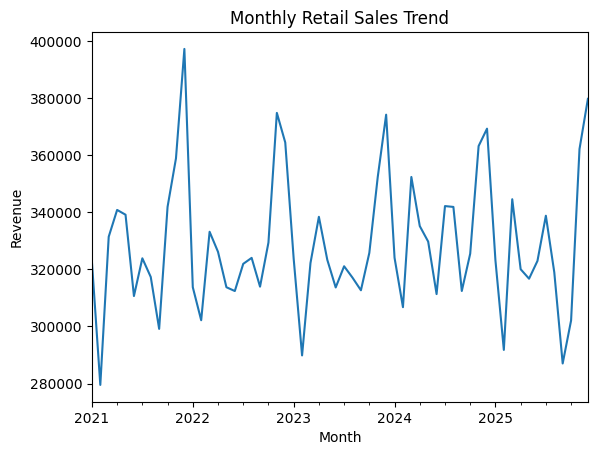

In [4]:
plt.figure()

monthly_sales.plot()

plt.title("Monthly Retail Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Moving Average (Trend Smoothing)

We apply a moving average to smooth short-term fluctuations and highlight long-term sales trends.

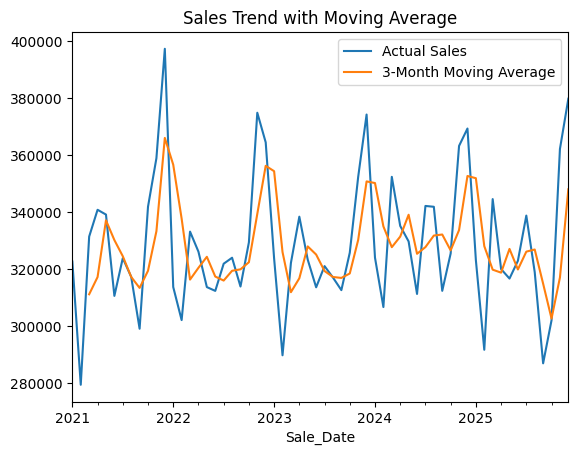

<Figure size 640x480 with 0 Axes>

In [6]:
sales_ma = monthly_sales.rolling(window=3).mean()

plt.figure()

monthly_sales.plot(label="Actual Sales")
sales_ma.plot(label="3-Month Moving Average")

plt.legend()
plt.title("Sales Trend with Moving Average")

plt.show()
plt.savefig("../images/moving_average_trend.png")

Seasonality Analysis

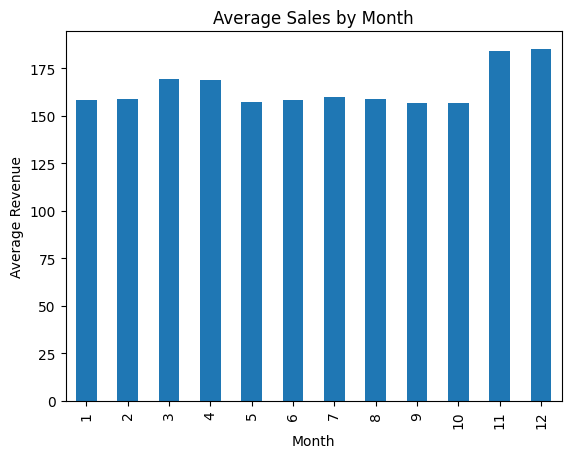

<Figure size 640x480 with 0 Axes>

In [8]:
sales['Month'] = sales['Sale_Date'].dt.month

seasonal_sales = sales.groupby('Month')['Total_Amount'].mean()

plt.figure()

seasonal_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.show()
plt.savefig("../images/seasonality_analysis.png")

Business Insights

Key Insights

• Sales show upward growth during holiday periods
• Peak demand occurs during months with major promotions
• Moving average reveals long-term sales growth trend
• Seasonal patterns suggest inventory should increase before peak months